In [2]:
import pandas as pd
import numpy as np

# 1. Generamos los datos simulados de 200 clientes (usando la semilla 42 para el azar)
np.random.seed(42)
datos_clientes = {
    'Edad': np.random.randint(18, 70, 200),
    'Ingreso_Anual_Miles': np.random.randint(15, 140, 200),
    'Puntaje_Gasto_1_100': np.random.randint(1, 100, 200)
}

# 2. Metemos los datos a nuestra tabla de Pandas
df_clientes = pd.DataFrame(datos_clientes)

# 3. Le echamos un vistazo a las primeras 5 filas
display(df_clientes.head())

,Edad,Ingreso_Anual_Miles,Puntaje_Gasto_1_100
0,56,84,61
1,69,86,48
2,46,41,19
3,32,23,4
4,60,76,35


In [4]:
from sklearn.cluster import KMeans

# 1. Le decimos al algoritmo que busque exactamente 5 grupos de clientes (clusters)
# Usamos random_state=42 por la misma razón que antes: para que a los dos nos dé igual
detective_kmeans = KMeans(n_clusters=5, random_state=42)

# 2. Solo usamos 2 columnas para el análisis: Ingresos y Gastos
# fit_predict entrena a la máquina y de una vez le pone una etiqueta del 0 al 4 a cada cliente
df_clientes['Grupo_Asignado'] = detective_kmeans.fit_predict(df_clientes[['Ingreso_Anual_Miles', 'Puntaje_Gasto_1_100']])

# 3. Vemos el resultado con la nueva columna que creó la IA
display(df_clientes.head())

C:\Users\minew\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Edad,Ingreso_Anual_Miles,Puntaje_Gasto_1_100,Grupo_Asignado
0,56,84,61,0
1,69,86,48,0
2,46,41,19,1
3,32,23,4,1
4,60,76,35,1


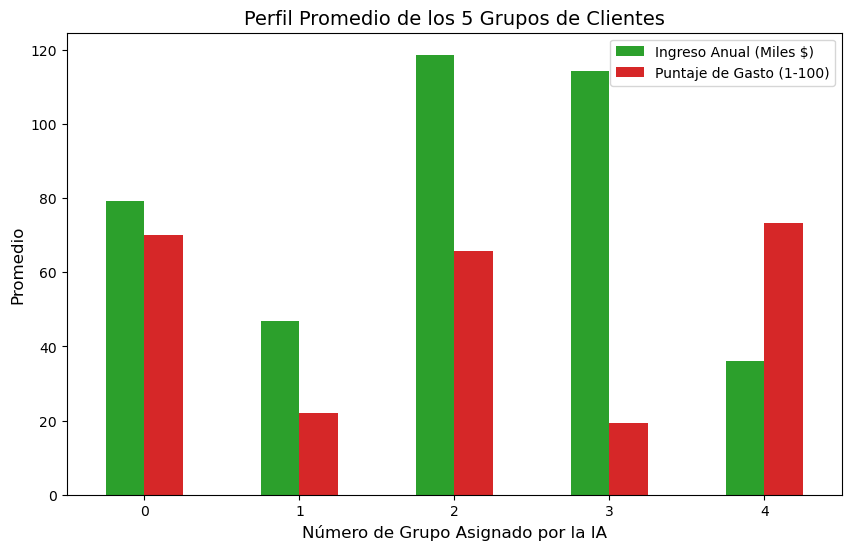

In [5]:
import matplotlib.pyplot as plt

# 1. Agrupamos nuestra tabla para calcular los promedios matemáticos de cada grupo
resumen_grupos = df_clientes.groupby('Grupo_Asignado').mean()

# 2. Le pedimos a Pandas que dibuje una gráfica de barras usando los ingresos y gastos
resumen_grupos[['Ingreso_Anual_Miles', 'Puntaje_Gasto_1_100']].plot(
    kind='bar', 
    figsize=(10, 6), 
    color=['#2ca02c', '#d62728'] # Verde para ingresos, Rojo para gastos
)

# 3. Decoramos la gráfica para que luzca profesional
plt.title('Perfil Promedio de los 5 Grupos de Clientes', fontsize=14)
plt.xlabel('Número de Grupo Asignado por la IA', fontsize=12)
plt.ylabel('Promedio', fontsize=12)
plt.xticks(rotation=0) # Para que los números de abajo no salgan chuecos
plt.legend(['Ingreso Anual (Miles $)', 'Puntaje de Gasto (1-100)'])

# Mostramos el lienzo
plt.show()
